# Real-World E-Commerce Dataset Analysis

## Project Overview

This project analyzes the Brazilian E-Commerce Public Dataset by Olist to understand sales patterns, delivery performance, and customer satisfaction.

The analysis focuses on relationships between order characteristics, delivery performance, and customer review scores using exploratory data analysis and data visualization.

The project follows a complete real-world data analysis workflow, including data exploration, data cleaning, preprocessing, exploratory analysis, visualization, interpretation, and conclusions.

## Analytical Problem

E-commerce businesses need to understand how order characteristics and delivery performance relate to customer satisfaction.

This project investigates the following questions:

- How do sales and order volumes vary over time?
- How does delivery performance vary across orders, products, and regions?
- Is delayed delivery associated with lower customer review scores?
- Which product categories and regions show differences in delivery performance?
- How are order value and freight costs related to customer satisfaction?
- What patterns in the data can provide useful business insights?

In [1]:
# import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Dataset Loading

The Olist dataset consists of multiple related tables representing different aspects of the e-commerce platform, including orders, customers, products, sellers, payments, reviews, and geolocation.

Each dataset will initially be loaded separately so that its structure, size, and contents can be examined before any preprocessing or integration is performed.

In [2]:
## Load the datasets
customers = pd.read_csv("../data/raw/olist_customers_dataset.csv")
geolocation = pd.read_csv("../data/raw/olist_geolocation_dataset.csv")
order_items = pd.read_csv("../data/raw/olist_order_items_dataset.csv")
order_payments = pd.read_csv("../data/raw/olist_order_payments_dataset.csv")
order_reviews = pd.read_csv("../data/raw/olist_order_reviews_dataset.csv")
orders = pd.read_csv("../data/raw/olist_orders_dataset.csv")
products = pd.read_csv("../data/raw/olist_products_dataset.csv")
sellers = pd.read_csv("../data/raw/olist_sellers_dataset.csv")
category_translation = pd.read_csv("../data/raw/product_category_name_translation.csv")

In [ ]:
# define the datasets
datasets = {
    "customers": customers,
    "geolocation": geolocation,
    "order_items": order_items,
    "order_payments": order_payments,
    "order_reviews": order_reviews,
    "orders": orders,
    "products": products,
    "sellers": sellers,
    "category_translation": category_translation
}

for name, df in datasets.items():
    print(f"{name}: {df.shape}")

customers: (99441, 5)
geolocation: (1000163, 5)
order_items: (112650, 7)
order_payments: (103886, 5)
order_reviews: (99224, 7)
orders: (99441, 8)
products: (32951, 9)
sellers: (3095, 4)
category_translation: (71, 2)


In [ ]:
# Investigate the columns of each dataset
for name, df in datasets.items():
    print(f"\n{'-' * 60}")
    print(f"{name.upper()}")
    print(f"{'-' * 60}")
    print(df.columns.tolist())


------------------------------------------------------------
CUSTOMERS
------------------------------------------------------------
['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

------------------------------------------------------------
GEOLOCATION
------------------------------------------------------------
['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng', 'geolocation_city', 'geolocation_state']

------------------------------------------------------------
ORDER_ITEMS
------------------------------------------------------------
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

------------------------------------------------------------
ORDER_PAYMENTS
------------------------------------------------------------
['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']

------------------------------------------------

In [ ]:
# Display the first few rows of each dataset
for name, df in datasets.items():
    print(f"\n{'-' * 60}")
    print(f"{name.upper()}")
    print(f"{'-' * 60}")
    display(df.head(3))


------------------------------------------------------------
CUSTOMERS
------------------------------------------------------------


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP



------------------------------------------------------------
GEOLOCATION
------------------------------------------------------------


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP



------------------------------------------------------------
ORDER_ITEMS
------------------------------------------------------------


...

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0



------------------------------------------------------------
SELLERS
------------------------------------------------------------


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ



------------------------------------------------------------
CATEGORY_TRANSLATION
------------------------------------------------------------


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto


## 2. Initial Data Understanding

The dataset contains multiple interconnected tables representing customers, orders, products, sellers, payments, reviews, and geographic information.

Before cleaning or combining the tables, their data types and data-quality characteristics will be examined independently. This helps identify variables that require type conversion, missing-value treatment, duplicate handling, or further investigation.

In [ ]:
# Display the data types of each dataset
for name, df in datasets.items():
    print(f"\n{'-' * 60}")
    print(f"{name.upper()}")
    print(f"{'-' * 60}")
    print(df.dtypes)


------------------------------------------------------------
CUSTOMERS
------------------------------------------------------------
customer_id                   str
customer_unique_id            str
customer_zip_code_prefix    int64
customer_city                 str
customer_state                str
dtype: object

------------------------------------------------------------
GEOLOCATION
------------------------------------------------------------
geolocation_zip_code_prefix      int64
geolocation_lat                float64
geolocation_lng                float64
geolocation_city                   str
geolocation_state                  str
dtype: object

------------------------------------------------------------
ORDER_ITEMS
------------------------------------------------------------
order_id                   str
order_item_id            int64
product_id                 str
seller_id                  str
shipping_limit_date        str
price                  float64
freight_value     

## 3. Data Quality Assessment

Before cleaning the datasets, their missing values and duplicate records will be assessed.

This step helps identify incomplete fields, repeated records, and potential quality issues that may affect later analysis. Missing values will be investigated based on the meaning of each variable rather than being removed automatically.

In [ ]:
# Check for missing values in each dataset
for name, df in datasets.items():
    missing = df.isna().sum()
    missing_pct = (missing / len(df)) * 100
    
    missing_report = pd.DataFrame({
        "missing_count": missing,
        "missing_percentage": missing_pct
    })
    
    missing_report = missing_report[missing_report["missing_count"] > 0]
    
    print(f"\n{'-' * 60}")
    print(f"{name.upper()}")
    print(f"{'-' * 60}")
    
    if missing_report.empty:
        print("No missing values found.")
    else:
        display(missing_report.sort_values("missing_percentage", ascending=False))


------------------------------------------------------------
CUSTOMERS
------------------------------------------------------------
No missing values found.

------------------------------------------------------------
GEOLOCATION
------------------------------------------------------------
No missing values found.

------------------------------------------------------------
ORDER_ITEMS
------------------------------------------------------------
No missing values found.

------------------------------------------------------------
ORDER_PAYMENTS
------------------------------------------------------------
No missing values found.

------------------------------------------------------------
ORDER_REVIEWS
------------------------------------------------------------


,missing_count,missing_percentage
review_comment_title,87656,88.341530
review_comment_message,58247,58.702532



------------------------------------------------------------
ORDERS
------------------------------------------------------------


,missing_count,missing_percentage
order_delivered_customer_date,2965,2.981668
order_delivered_carrier_date,1783,1.793023
order_approved_at,160,0.160899



------------------------------------------------------------
PRODUCTS
------------------------------------------------------------


,missing_count,missing_percentage
product_category_name,610,1.851234
product_name_lenght,610,1.851234
product_description_lenght,610,1.851234
product_photos_qty,610,1.851234
product_weight_g,2,0.006070
product_length_cm,2,0.006070
product_height_cm,2,0.006070
product_width_cm,2,0.006070



------------------------------------------------------------
SELLERS
------------------------------------------------------------
No missing values found.

------------------------------------------------------------
CATEGORY_TRANSLATION
------------------------------------------------------------
No missing values found.


In [ ]:
# Check for duplicate rows in each dataset
for name, df in datasets.items():
    duplicate_count = df.duplicated().sum()
    duplicate_percentage = (duplicate_count / len(df)) * 100
    
    print(f"\n{'-' * 60}")
    print(f"{name.upper()}")
    print(f"{'-' * 60}")
    print(f"Duplicate rows: {duplicate_count}")
    print(f"Duplicate percentage: {duplicate_percentage:.2f}%")


------------------------------------------------------------
CUSTOMERS
------------------------------------------------------------
Duplicate rows: 0
Duplicate percentage: 0.00%

------------------------------------------------------------
GEOLOCATION
------------------------------------------------------------
Duplicate rows: 261831
Duplicate percentage: 26.18%

------------------------------------------------------------
ORDER_ITEMS
------------------------------------------------------------
Duplicate rows: 0
Duplicate percentage: 0.00%

------------------------------------------------------------
ORDER_PAYMENTS
------------------------------------------------------------
Duplicate rows: 0
Duplicate percentage: 0.00%

------------------------------------------------------------
ORDER_REVIEWS
------------------------------------------------------------
Duplicate rows: 0
Duplicate percentage: 0.00%

------------------------------------------------------------
ORDERS
-----------------

In [ ]:
# Create a summary of the data quality for each dataset
quality_summary = []

for name, df in datasets.items():
    quality_summary.append({
        "dataset": name,
        "rows": len(df),
        "columns": len(df.columns),
        "missing_cells": int(df.isna().sum().sum()),
        "duplicate_rows": int(df.duplicated().sum())
    })

quality_summary = pd.DataFrame(quality_summary)

display(quality_summary)

,dataset,rows,columns,missing_cells,duplicate_rows
0,customers,99441,5,0,0
1,geolocation,1000163,5,0,261831
2,order_items,112650,7,0,0
3,order_payments,103886,5,0,0
4,order_reviews,99224,7,145903,0
5,orders,99441,8,4908,0
6,products,32951,9,2448,0
7,sellers,3095,4,0,0
8,category_translation,71,2,0,0


In [ ]:
# Check for duplicate rows in the geolocation dataset based on specific columns
geo_duplicates = geolocation[
    geolocation.duplicated(keep=False)
].sort_values(
    by=["geolocation_zip_code_prefix", "geolocation_lat", "geolocation_lng"]
)

print(f"Rows involved in duplicate groups: {len(geo_duplicates)}")
print(f"Unique duplicate rows: {geo_duplicates.drop_duplicates().shape[0]}")

display(geo_duplicates.head(20))

Rows involved in duplicate groups: 390005
Unique duplicate rows: 128174


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
519,1001,-23.551337,-46.634027,sao paulo,SP
583,1001,-23.551337,-46.634027,sao paulo,SP
818,1001,-23.551337,-46.634027,sao paulo,SP
206,1001,-23.550498,-46.634338,sao paulo,SP
429,1001,-23.550498,-46.634338,sao paulo,SP
596,1001,-23.550498,-46.634338,sao paulo,SP
639,1001,-23.550498,-46.634338,sao paulo,SP
771,1001,-23.550498,-46.634338,sao paulo,SP
912,1001,-23.550498,-46.634338,sao paulo,SP
985,1001,-23.550498,-46.634338,sao paulo,SP


In [ ]:
# Investigate the orders dataset for missing values
order_missing = orders[orders.isna().any(axis=1)].copy()

print(f"Orders with at least one missing value: {len(order_missing)}")

display(
    order_missing.groupby("order_status")
    .size()
    .sort_values(ascending=False)
    .to_frame("orders_with_missing_values")
)

Orders with at least one missing value: 2980


,orders_with_missing_values
order_status,
shipped,1107
canceled,619
unavailable,609
invoiced,314
processing,301
delivered,23
created,5
approved,2


In [ ]:
# Investigate the missing values in the order date columns by order status
order_date_columns = [
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

missing_by_status = (
    orders.groupby("order_status")[order_date_columns]
    .apply(lambda df: df.isna().sum())
)

display(missing_by_status)

,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
order_status,,,,
approved,0,2,2,0
canceled,141,550,619,0
created,5,5,5,0
delivered,14,2,8,0
invoiced,0,314,314,0
processing,0,301,301,0
shipped,0,0,1107,0
unavailable,0,609,609,0


In [ ]:
# Identify delivered orders with missing timestamps
delivered_missing_dates = orders[
    (orders["order_status"] == "delivered") &
    (orders[order_date_columns].isna().any(axis=1))
].copy()

print(f"Delivered orders with missing timestamps: {len(delivered_missing_dates)}")

display(delivered_missing_dates)

Delivered orders with missing timestamps: 23


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
3002,2d1e2d5bf4dc7227b3bfebb81328c15f,ec05a6d8558c6455f0cbbd8a420ad34f,delivered,2017-11-28 17:44:07,2017-11-28 17:56:40,2017-11-30 18:12:23,NaN,2017-12-18 00:00:00
5323,e04abd8149ef81b95221e88f6ed9ab6a,2127dc6603ac33544953ef05ec155771,delivered,2017-02-18 14:40:00,NaN,2017-02-23 12:04:47,2017-03-01 13:25:33,2017-03-17 00:00:00
16567,8a9adc69528e1001fc68dd0aaebbb54a,4c1ccc74e00993733742a3c786dc3c1f,delivered,2017-02-18 12:45:31,NaN,2017-02-23 09:01:52,2017-03-02 10:05:06,2017-03-21 00:00:00
19031,7013bcfc1c97fe719a7b5e05e61c12db,2941af76d38100e0f8740a374f1a5dc3,delivered,2017-02-18 13:29:47,NaN,2017-02-22 16:25:25,2017-03-01 08:07:38,2017-03-17 00:00:00
20618,f5dd62b788049ad9fc0526e3ad11a097,5e89028e024b381dc84a13a3570decb4,delivered,2018-06-20 06:58:43,2018-06-20 07:19:05,2018-06-25 08:05:00,NaN,2018-07-16 00:00:00
22663,5cf925b116421afa85ee25e99b4c34fb,29c35fc91fc13fb5073c8f30505d860d,delivered,2017-02-18 16:48:35,NaN,2017-02-22 11:23:10,2017-03-09 07:28:47,2017-03-31 00:00:00
23156,12a95a3c06dbaec84bcfb0e2da5d228a,1e101e0daffaddce8159d25a8e53f2b2,delivered,2017-02-17 13:05:55,NaN,2017-02-22 11:23:11,2017-03-02 11:09:19,2017-03-20 00:00:00
26800,c1d4211b3dae76144deccd6c74144a88,684cb238dc5b5d6366244e0e0776b450,delivered,2017-01-19 12:48:08,NaN,2017-01-25 14:56:50,2017-01-30 18:16:01,2017-03-01 00:00:00
38290,d69e5d356402adc8cf17e08b5033acfb,68d081753ad4fe22fc4d410a9eb1ca01,delivered,2017-02-19 01:28:47,NaN,2017-02-23 03:11:48,2017-03-02 03:41:58,2017-03-27 00:00:00
39334,d77031d6a3c8a52f019764e68f211c69,0bf35cac6cc7327065da879e2d90fae8,delivered,2017-02-18 11:04:19,NaN,2017-02-23 07:23:36,2017-03-02 16:15:23,2017-03-22 00:00:00


In [ ]:
# Investigate the products dataset for missing values
product_missing = products[products.isna().any(axis=1)].copy()

print(f"Products with at least one missing value: {len(product_missing)}")

display(product_missing)

Products with at least one missing value: 611


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
105,a41e356c76fab66334f36de622ecbd3a,NaN,NaN,NaN,NaN,650.0,17.0,14.0,12.0
128,d8dee61c2034d6d075997acef1870e9b,NaN,NaN,NaN,NaN,300.0,16.0,7.0,20.0
145,56139431d72cd51f19eb9f7dae4d1617,NaN,NaN,NaN,NaN,200.0,20.0,20.0,20.0
154,46b48281eb6d663ced748f324108c733,NaN,NaN,NaN,NaN,18500.0,41.0,30.0,41.0
197,5fb61f482620cb672f5e586bb132eae9,NaN,NaN,NaN,NaN,300.0,35.0,7.0,12.0
...,...,...,...,...,...,...,...,...,...
32515,b0a0c5dd78e644373b199380612c350a,NaN,NaN,NaN,NaN,1800.0,30.0,20.0,70.0
32589,10dbe0fbaa2c505123c17fdc34a63c56,NaN,NaN,NaN,NaN,800.0,30.0,10.0,23.0
32616,bd2ada37b58ae94cc838b9c0569fecd8,NaN,NaN,NaN,NaN,200.0,21.0,8.0,16.0
32772,fa51e914046aab32764c41356b9d4ea4,NaN,NaN,NaN,NaN,1300.0,45.0,16.0,45.0


In [ ]:
# Analyze the pattern of missing values in the products dataset
product_missing_pattern = (
    products.isna()
    .groupby([
        "product_category_name",
        "product_name_lenght",
        "product_description_lenght",
        "product_photos_qty",
        "product_weight_g",
        "product_length_cm",
        "product_height_cm",
        "product_width_cm"
    ])
    .size()
    .reset_index(name="product_count")
)

display(product_missing_pattern)

,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_count
0,False,False,False,False,False,False,False,False,32340
1,False,False,False,False,True,True,True,True,1
2,True,True,True,True,False,False,False,False,609
3,True,True,True,True,True,True,True,True,1


In [ ]:
# Analyze the order reviews dataset for duplicate order IDs
reviews_per_order = order_reviews.groupby("order_id").size()

print(f"Unique orders with reviews: {reviews_per_order.size}")
print(f"Orders with more than one review record: {(reviews_per_order > 1).sum()}")
print(f"Maximum reviews for a single order: {reviews_per_order.max()}")

display(
    reviews_per_order.value_counts()
    .sort_index()
    .to_frame("number_of_orders")
)

Unique orders with reviews: 98673
Orders with more than one review record: 547
Maximum reviews for a single order: 3


,number_of_orders
1,98126
2,543
3,4


In [ ]:
# Identify orders with multiple reviews
multiple_review_orders = reviews_per_order[reviews_per_order > 1].index

multiple_reviews = (
    order_reviews[
        order_reviews["order_id"].isin(multiple_review_orders)
    ]
    .sort_values("order_id")
)

display(multiple_reviews.head(20))

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
25612,89a02c45c340aeeb1354a24e7d4b2c1e,0035246a40f520710769010f752e7507,5,NaN,NaN,2017-08-29 00:00:00,2017-08-30 01:59:12
22423,2a74b0559eb58fc1ff842ecc999594cb,0035246a40f520710769010f752e7507,5,NaN,Estou acostumada a comprar produtos pelo barat...,2017-08-25 00:00:00,2017-08-29 21:45:57
22779,ab30810c29da5da8045216f0f62652a2,013056cfe49763c6f66bda03396c5ee3,5,NaN,NaN,2018-02-22 00:00:00,2018-02-23 12:12:30
68633,73413b847f63e02bc752b364f6d05ee9,013056cfe49763c6f66bda03396c5ee3,4,NaN,NaN,2018-03-04 00:00:00,2018-03-05 17:02:00
854,830636803620cdf8b6ffaf1b2f6e92b2,0176a6846bcb3b0d3aa3116a9a768597,5,NaN,NaN,2017-12-30 00:00:00,2018-01-02 10:54:06
83224,d8e8c42271c8fb67b9dad95d98c8ff80,0176a6846bcb3b0d3aa3116a9a768597,5,NaN,NaN,2017-12-30 00:00:00,2018-01-02 10:54:47
17582,017f0e1ea6386de662cbeba299c59ad1,02355020fd0a40a0d56df9f6ff060413,1,NaN,ja reclamei varias vezes e ate hoje não sei on...,2018-03-29 00:00:00,2018-03-30 03:16:19
89888,0c8e7347f1cdd2aede37371543e3d163,02355020fd0a40a0d56df9f6ff060413,3,NaN,UM DOS PRODUTOS (ENTREGA02) COMPRADOS NESTE PE...,2018-03-21 00:00:00,2018-03-22 01:32:08
55137,61fe4e7d1ae801bbe169eb67b86c6eda,029863af4b968de1e5d6a82782e662f5,4,NaN,NaN,2017-07-19 00:00:00,2017-07-20 12:06:11
37911,04d945e95c788a3aa1ffbee42105637b,029863af4b968de1e5d6a82782e662f5,5,NaN,NaN,2017-07-14 00:00:00,2017-07-17 13:58:06


## 4. Data Cleaning and Preprocessing

The raw datasets will now be cleaned while preserving the original data files.

The cleaning process includes removing exact duplicate records where appropriate, converting date fields to datetime format, and preparing missing values for analysis based on their meaning and role in the dataset.

No values will be artificially imputed when doing so could introduce assumptions into the analysis.

In [ ]:
# Create a copy of the datasets for cleaning and preprocessing
cleaned_datasets = {
    name: df.copy()
    for name, df in datasets.items()
}

customers_clean = cleaned_datasets["customers"]
geolocation_clean = cleaned_datasets["geolocation"]
order_items_clean = cleaned_datasets["order_items"]
order_payments_clean = cleaned_datasets["order_payments"]
order_reviews_clean = cleaned_datasets["order_reviews"]
orders_clean = cleaned_datasets["orders"]
products_clean = cleaned_datasets["products"]
sellers_clean = cleaned_datasets["sellers"]
category_translation_clean = cleaned_datasets["category_translation"]

In [ ]:
# Clean the geolocation dataset by removing duplicate rows
before = len(geolocation_clean)

geolocation_clean = geolocation_clean.drop_duplicates().reset_index(drop=True)

after = len(geolocation_clean)

print(f"Rows before cleaning: {before}")
print(f"Rows after cleaning: {after}")
print(f"Duplicate rows removed: {before - after}")

Rows before cleaning: 1000163
Rows after cleaning: 738332
Duplicate rows removed: 261831


In [ ]:
# Convert date columns to datetime format
order_date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

review_date_columns = [
    "review_creation_date",
    "review_answer_timestamp"
]

order_items_clean["shipping_limit_date"] = pd.to_datetime(
    order_items_clean["shipping_limit_date"]
)

orders_clean[order_date_columns] = orders_clean[order_date_columns].apply(
    pd.to_datetime
)

order_reviews_clean[review_date_columns] = order_reviews_clean[
    review_date_columns
].apply(pd.to_datetime)

In [ ]:
# Fill missing values in the product category name column with "unknown"
products_clean["product_category_name"] = (
    products_clean["product_category_name"].fillna("unknown")
)

products_clean["product_category_name"].isna().sum()

np.int64(0)

In [ ]:
# Fill missing values in the review comment title and message columns with "no_title" and "no_comment" respectively
order_reviews_clean["review_comment_title"] = (
    order_reviews_clean["review_comment_title"].fillna("no_title")
)

order_reviews_clean["review_comment_message"] = (
    order_reviews_clean["review_comment_message"].fillna("no_comment")
)

print("Missing review titles:", order_reviews_clean["review_comment_title"].isna().sum())
print("Missing review messages:", order_reviews_clean["review_comment_message"].isna().sum())

Missing review titles: 0
Missing review messages: 0


## 5. Feature Preparation

After handling the identified missing values and duplicate records, the datasets will be prepared for analysis.

This stage focuses on creating useful variables from the existing data, standardizing categorical information, and preparing the related tables for integration.

Derived features will be created only when they directly support the project's analytical questions.

In [ ]:
# Calculate the delivery time in days for each order
orders_clean["delivery_time_days"] = (
    orders_clean["order_delivered_customer_date"]
    - orders_clean["order_purchase_timestamp"]
).dt.total_seconds() / (24 * 60 * 60)

orders_clean["delivery_time_days"].describe()

count    96476.000000
mean        12.558702
std          9.546530
min          0.533414
25%          6.766403
50%         10.217755
75%         15.720327
max        209.628611
Name: delivery_time_days, dtype: float64

In [ ]:
# Identify orders with delivery time above 60 days
extreme_delivery = orders_clean[
    orders_clean["delivery_time_days"] > 60
].sort_values(
    "delivery_time_days",
    ascending=False
)

print(f"Orders with delivery time above 60 days: {len(extreme_delivery)}")

display(
    extreme_delivery[
        [
            "order_id",
            "order_status",
            "order_purchase_timestamp",
            "order_delivered_customer_date",
            "order_estimated_delivery_date",
            "delivery_time_days"
        ]
    ].head(20)
)

Orders with delivery time above 60 days: 306


,order_id,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,delivery_time_days
19590,ca07593549f1816d26a572e06dc1eab6,delivered,2017-02-21 23:31:27,2017-09-19 14:36:39,2017-03-22,209.628611
55619,1b3190b2dfa9d789e1f14c05b647a14a,delivered,2018-02-23 14:57:35,2018-09-19 23:24:07,2018-03-15,208.351759
61610,440d0d17af552815d15a9e41abe49359,delivered,2017-03-07 23:59:51,2017-09-19 15:12:50,2017-04-07,195.634016
70307,2fb597c2f772eca01b1f5c561bf6cc7b,delivered,2017-03-08 18:09:02,2017-09-19 14:33:17,2017-04-17,194.850174
89130,285ab9426d6982034523a855f55a885e,delivered,2017-03-08 22:47:40,2017-09-19 14:00:04,2017-04-06,194.633611
38509,0f4519c5f1c541ddec9f21b3bddd533a,delivered,2017-03-09 13:26:57,2017-09-19 14:38:21,2017-04-11,194.049583
11399,47b40429ed8cce3aee9199792275433f,delivered,2018-01-03 09:44:01,2018-07-13 20:51:31,2018-01-19,191.463542
81401,2fe324febf907e3ea3f2aa9650869fa5,delivered,2017-03-13 20:17:10,2017-09-19 17:00:07,2017-04-05,189.863160
54480,2d7561026d542c8dbd8f0daeadf67a43,delivered,2017-03-15 11:24:27,2017-09-19 14:38:18,2017-04-13,188.134618
68769,c27815f7e3dd0b926b58552628481575,delivered,2017-03-15 23:23:17,2017-09-19 17:14:25,2017-04-10,187.743843


In [ ]:
# Calculate the delivery delay in days for each order
orders_clean["delivery_delay_days"] = (
    orders_clean["order_delivered_customer_date"]
    - orders_clean["order_estimated_delivery_date"]
).dt.total_seconds() / (24 * 60 * 60)

orders_clean["is_late"] = orders_clean["delivery_delay_days"] > 0

print("Delivery delay statistics:")
print(orders_clean["delivery_delay_days"].describe())

print("\nLate delivery counts:")
print(orders_clean["is_late"].value_counts())

Delivery delay statistics:
count    96476.000000
mean       -11.179120
std         10.186113
min       -146.016123
25%        -16.244384
50%        -11.948941
75%         -6.390000
max        188.975081
Name: delivery_delay_days, dtype: float64

Late delivery counts:
is_late
False    91614
True      7827
Name: count, dtype: int64


## 6. Order-Level Feature Engineering

The order items table contains multiple records for orders that include more than one product. To perform order-level analysis without creating duplicate order records, item-level information is aggregated by `order_id`.

The following features are created:

- **Total Order Value** — total product price within an order.
- **Total Freight Value** — total freight cost associated with an order.
- **Total Items** — number of items included in an order.

These features will later be used to examine relationships between order characteristics, delivery performance, and customer satisfaction.

In [ ]:
# Calculate the total order value, total freight value, and total number of items for each order
order_value_summary = (
    order_items_clean
    .groupby("order_id")
    .agg(
        total_order_value=("price", "sum"),
        total_freight_value=("freight_value", "sum"),
        total_items=("order_item_id", "count")
    )
    .reset_index()
)

print("Order-level value summary:")
display(order_value_summary.head())

print("\nSummary statistics:")
display(order_value_summary[
    ["total_order_value", "total_freight_value", "total_items"]
].describe())

Order-level value summary:


,order_id,total_order_value,total_freight_value,total_items
0,00010242fe8c5a6d1ba2dd792cb16214,58.90,13.29,1
1,00018f77f2f0320c557190d7a144bdd3,239.90,19.93,1
2,000229ec398224ef6ca0657da4fc703e,199.00,17.87,1
3,00024acbcdf0a6daa1e931b038114c75,12.99,12.79,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90,18.14,1



Summary statistics:


,total_order_value,total_freight_value,total_items
count,98666.000000,98666.000000,98666.000000
mean,137.754076,22.823562,1.141731
std,210.645145,21.650909,0.538452
min,0.850000,0.000000,1.000000
25%,45.900000,13.850000,1.000000
50%,86.900000,17.170000,1.000000
75%,149.900000,24.040000,1.000000
max,13440.000000,1794.960000,21.000000


In [ ]:
# Merge the order value summary with the main orders dataset
orders_clean = orders_clean.merge(
    order_value_summary,
    on="order_id",
    how="left"
)

print("Orders dataset shape:", orders_clean.shape)

display(
    orders_clean[
        [
            "order_id",
            "total_order_value",
            "total_freight_value",
            "total_items"
        ]
    ].head()
)

Orders dataset shape: (99441, 14)


,order_id,total_order_value,total_freight_value,total_items
0,e481f51cbdc54678b7cc49136f2d6af7,29.99,8.72,1.0
1,53cdb2fc8bc7dce0b6741e2150273451,118.70,22.76,1.0
2,47770eb9100c2d0c44946d9cf07ec65d,159.90,19.22,1.0
3,949d5b44dbf5de918fe9c16f97b45f8a,45.00,27.20,1.0
4,ad21c59c0840e6cb83a9ceb5573f8159,19.90,8.72,1.0


## 7. Customer Satisfaction Features

Customer reviews provide a measure of customer satisfaction with completed orders.

Because some orders have multiple review records, review information will be aggregated at the order level before being combined with the main orders dataset.

The analysis will use the average review score and the number of review records associated with each order. This preserves the available review information while maintaining one row per order in the main analysis dataset.

In [ ]:
# Calculate the average review score and review count for each order
review_summary = (
    order_reviews_clean
    .groupby("order_id")
    .agg(
        average_review_score=("review_score", "mean"),
        review_count=("review_id", "count")
    )
    .reset_index()
)

print("Order-level review summary:")
display(review_summary.head())

print("\nSummary statistics:")
display(
    review_summary[
        ["average_review_score", "review_count"]
    ].describe()
)

Order-level review summary:


,order_id,average_review_score,review_count
0,00010242fe8c5a6d1ba2dd792cb16214,5.0,1
1,00018f77f2f0320c557190d7a144bdd3,4.0,1
2,000229ec398224ef6ca0657da4fc703e,5.0,1
3,00024acbcdf0a6daa1e931b038114c75,4.0,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,5.0,1



Summary statistics:


,average_review_score,review_count
count,98673.000000,98673.000000
mean,4.086793,1.005584
std,1.346274,0.075060
min,1.000000,1.000000
25%,4.000000,1.000000
50%,5.000000,1.000000
75%,5.000000,1.000000
max,5.000000,3.000000


In [ ]:
# Merge the review summary with the main orders dataset
orders_clean = orders_clean.merge(
    review_summary,
    on="order_id",
    how="left"
)

print("Orders dataset shape:", orders_clean.shape)

display(
    orders_clean[
        [
            "order_id",
            "average_review_score",
            "review_count"
        ]
    ].head()
)

Orders dataset shape: (99441, 16)


,order_id,average_review_score,review_count
0,e481f51cbdc54678b7cc49136f2d6af7,4.0,1.0
1,53cdb2fc8bc7dce0b6741e2150273451,4.0,1.0
2,47770eb9100c2d0c44946d9cf07ec65d,5.0,1.0
3,949d5b44dbf5de918fe9c16f97b45f8a,5.0,1.0
4,ad21c59c0840e6cb83a9ceb5573f8159,5.0,1.0


## 8. Product and Category Features

Product information is stored separately from the order table and is connected through the order items table.

The product category will be translated from Portuguese to English using the provided category translation table. Product-level information will then be connected to order items so that category-specific patterns can be examined without altering the one-row-per-order structure of the main order dataset.

Because a single order may contain multiple products or categories, category-level analysis will be performed at the appropriate item level rather than assigning one category arbitrarily to an entire order.

In [ ]:
# Merge the category translation with the products dataset
products_clean = products_clean.merge(
    category_translation_clean,
    on="product_category_name",
    how="left"
)

products_clean["product_category_name_english"] = (
    products_clean["product_category_name_english"]
    .fillna(products_clean["product_category_name"])
)

print("Products dataset shape:", products_clean.shape)

display(
    products_clean[
        [
            "product_id",
            "product_category_name",
            "product_category_name_english"
        ]
    ].head(10)
)

Products dataset shape: (32951, 10)


,product_id,product_category_name,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,housewares
5,41d3672d4792049fa1779bb35283ed13,instrumentos_musicais,musical_instruments
6,732bd381ad09e530fe0a5f457d81becb,cool_stuff,cool_stuff
7,2548af3e6e77a690cf3eb6368e9ab61e,moveis_decoracao,furniture_decor
8,37cc742be07708b53a98702e77a21a02,eletrodomesticos,home_appliances
9,8c92109888e8cdf9d66dc7e463025574,brinquedos,toys


## 9. Order-Item Analysis Dataset

The order items table connects individual orders with products and sellers.

For category-level analysis, an order-item dataset will be created by combining order item information with product categories and selected order-level delivery and satisfaction features.

This dataset will retain one row per order item. This is important because an order may contain multiple products or categories, and assigning a single category to such an order would introduce unnecessary assumptions.

In [6]:
# Create a combined dataset for order-item analysis by merging order items, products, and orders datasets
order_item_analysis = order_items_clean.merge(
    products_clean[
        [
            "product_id",
            "product_category_name_english"
        ]
    ],
    on="product_id",
    how="left"
)

order_item_analysis = order_item_analysis.merge(
    orders_clean[
        [
            "order_id",
            "delivery_time_days",
            "delivery_delay_days",
            "is_late",
            "total_order_value",
            "total_freight_value",
            "average_review_score"
        ]
    ],
    on="order_id",
    how="left"
)

print("Order-item analysis shape:", order_item_analysis.shape)

display(order_item_analysis.head())

Order-item analysis shape: (112650, 14)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name_english,delivery_time_days,delivery_delay_days,is_late,total_order_value,total_freight_value,average_review_score
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,7.614421,-8.011250,False,58.90,13.29,5.0
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,16.216181,-2.330278,False,239.90,19.93,4.0
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,furniture_decor,7.948437,-13.444954,False,199.00,17.87,5.0
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumery,6.147269,-5.435660,False,12.99,12.79,4.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,garden_tools,25.114352,-15.303808,False,199.90,18.14,5.0


## 10. Exploratory Data Analysis

The cleaned and feature-engineered datasets are now ready for exploratory analysis.

The EDA focuses on understanding sales activity, delivery performance, and customer satisfaction through distributions, trends, group-wise comparisons, and relationships between important variables.

The analysis will be question-driven rather than based on a fixed number of visualizations. Observed patterns will be distinguished from assumptions, and potential anomalies will be investigated before drawing conclusions.

In [7]:
# Display information about the orders dataset
print("Orders dataset shape:", orders_clean.shape)

print("\nOrder-level columns:")
print(orders_clean.columns.tolist())

print("\nData types:")
display(orders_clean.dtypes.to_frame("dtype"))

Orders dataset shape: (99441, 16)

Order-level columns:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'delivery_time_days', 'delivery_delay_days', 'is_late', 'total_order_value', 'total_freight_value', 'total_items', 'average_review_score', 'review_count']

Data types:


,dtype
order_id,str
customer_id,str
order_status,str
order_purchase_timestamp,datetime64[us]
order_approved_at,datetime64[us]
order_delivered_carrier_date,datetime64[us]
order_delivered_customer_date,datetime64[us]
order_estimated_delivery_date,datetime64[us]
delivery_time_days,float64
delivery_delay_days,float64


## 11. Sales and Order Volume Over Time

The first EDA question is how e-commerce activity changed over the period covered by the dataset.

Monthly order volume and sales value will be examined to identify changes in purchasing activity and overall sales patterns over time.

In [9]:
# Display summary statistics for numeric columns in the orders dataset
orders_clean["order_month"] = (
    orders_clean["order_purchase_timestamp"]
    .dt.to_period("M")
)

monthly_sales = (
    orders_clean
    .groupby("order_month")
    .agg(
        order_count=("order_id", "nunique"),
        total_sales=("total_order_value", "sum")
    )
    .reset_index()
)

monthly_sales["order_month"] = monthly_sales["order_month"].astype(str)

display(monthly_sales)

,order_month,order_count,total_sales
0,2016-09,4,267.36
1,2016-10,324,49507.66
2,2016-12,1,10.90
3,2017-01,800,120312.87
4,2017-02,1780,247303.02
5,2017-03,2682,374344.30
6,2017-04,2404,359927.23
7,2017-05,3700,506071.14
8,2017-06,3245,433038.60
9,2017-07,4026,498031.48


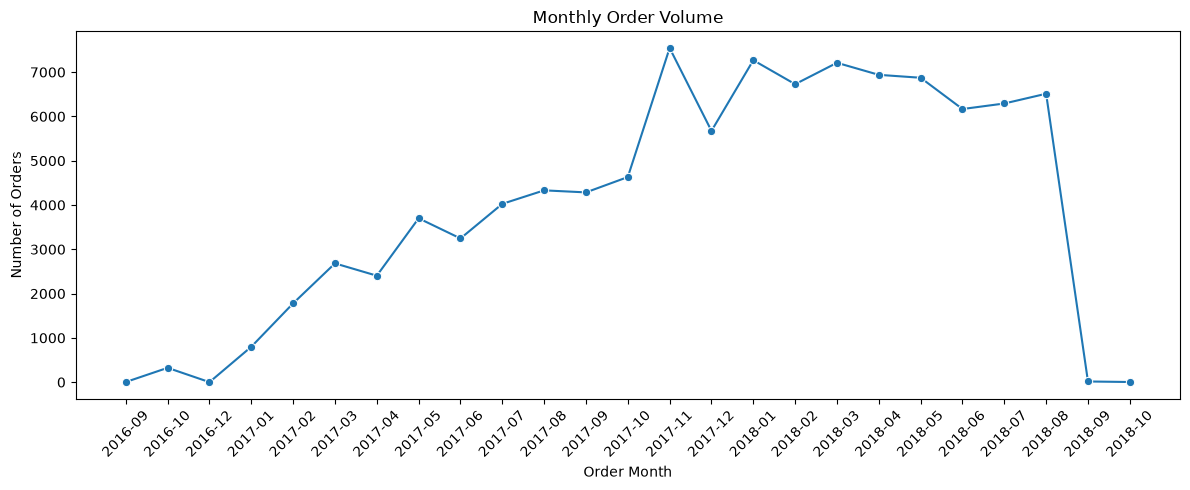

In [10]:
# Visualize the monthly order volume using a line plot
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=monthly_sales,
    x="order_month",
    y="order_count",
    marker="o"
)

plt.title("Monthly Order Volume")
plt.xlabel("Order Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 12. Monthly Sales Value

Order volume shows how purchasing activity changes over time, but the number of orders alone does not indicate the monetary value of sales.

Monthly total order value will therefore be examined to determine whether changes in sales value follow the same pattern as changes in order volume.

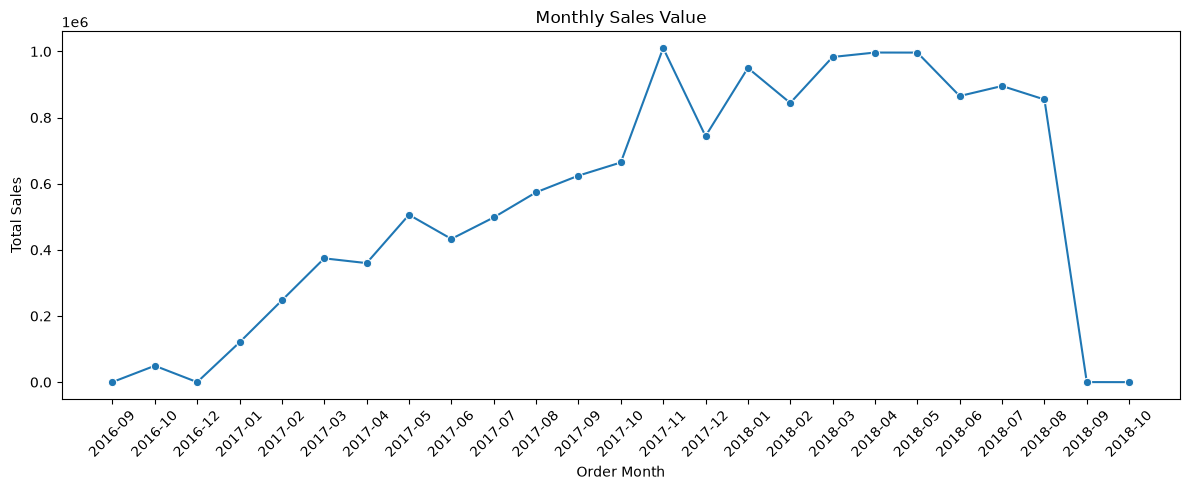

In [12]:
# Visualize the monthly sales value using a line plot
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=monthly_sales,
    x="order_month",
    y="total_sales",
    marker="o"
)

plt.title("Monthly Sales Value")
plt.xlabel("Order Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 13. Delivery Performance Over Time

Delivery performance is a central part of the analysis because delays may be associated with customer dissatisfaction.

Monthly delivery time and the proportion of late deliveries will be examined to identify changes in fulfillment performance over the observed period.

In [13]:
# Calculate monthly delivery performance metrics
monthly_delivery = (
    orders_clean[
        orders_clean["delivery_time_days"].notna()
    ]
    .groupby(
        orders_clean.loc[
            orders_clean["delivery_time_days"].notna(),
            "order_purchase_timestamp"
        ].dt.to_period("M")
    )
    .agg(
        average_delivery_time=("delivery_time_days", "mean"),
        median_delivery_time=("delivery_time_days", "median"),
        late_order_count=("is_late", "sum"),
        order_count=("order_id", "nunique")
    )
    .reset_index()
)

monthly_delivery["late_delivery_rate"] = (
    monthly_delivery["late_order_count"]
    / monthly_delivery["order_count"]
    * 100
)

monthly_delivery["order_purchase_timestamp"] = (
    monthly_delivery["order_purchase_timestamp"].astype(str)
)

display(monthly_delivery)

,order_purchase_timestamp,average_delivery_time,median_delivery_time,late_order_count,order_count,late_delivery_rate
0,2016-09,54.813194,54.813194,1,1,100.000000
1,2016-10,19.578572,17.921157,3,270,1.111111
2,2016-12,4.693021,4.693021,0,1,0.000000
3,2017-01,12.647044,10.733646,23,750,3.066667
4,2017-02,13.168825,10.971204,53,1653,3.206292
5,2017-03,12.951184,10.126487,142,2546,5.577376
6,2017-04,14.917913,12.748623,181,2303,7.859314
7,2017-05,11.322363,9.793333,128,3545,3.610719
8,2017-06,12.011573,10.804907,121,3135,3.859649
9,2017-07,11.592732,10.158073,133,3872,3.434917


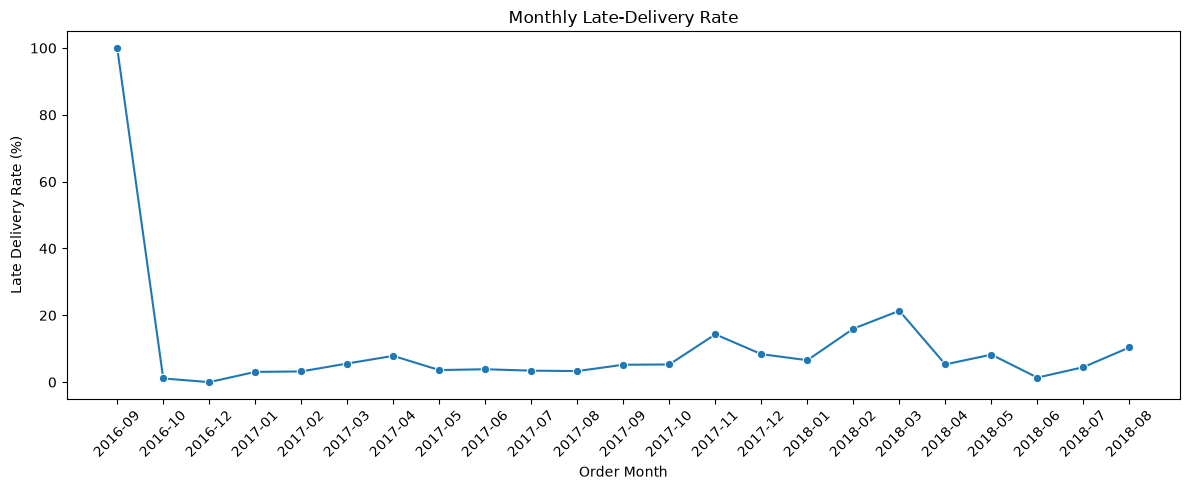

In [14]:
# Visualize the monthly late-delivery rate using a line plot
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=monthly_delivery,
    x="order_purchase_timestamp",
    y="late_delivery_rate",
    marker="o"
)

plt.title("Monthly Late-Delivery Rate")
plt.xlabel("Order Month")
plt.ylabel("Late Delivery Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 14. Delivery Performance and Customer Satisfaction

One of the central questions of this project is whether delivery performance is associated with customer satisfaction.

Customer review scores will be compared between orders delivered on time and orders delivered late. The analysis will identify differences in observed review scores without assuming that delivery delays directly cause lower satisfaction.

In [15]:
# Analyze the relationship between delivery performance and customer reviews
delivery_review_summary = (
    orders_clean[
        orders_clean["average_review_score"].notna()
    ]
    .groupby("is_late")
    .agg(
        order_count=("order_id", "nunique"),
        average_review_score=("average_review_score", "mean"),
        median_review_score=("average_review_score", "median")
    )
    .reset_index()
)

display(delivery_review_summary)

,is_late,order_count,average_review_score,median_review_score
0,False,91011,4.214778,5.0
1,True,7662,2.566562,2.0


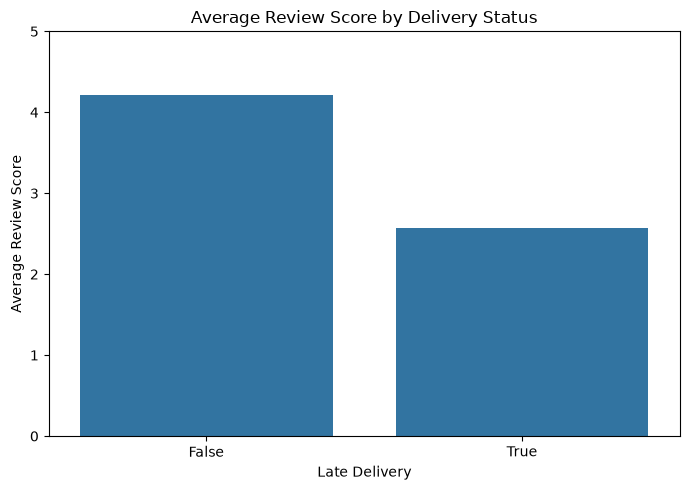

In [16]:
# Visualize the average review score by delivery status using a bar plot
plt.figure(figsize=(7, 5))

sns.barplot(
    data=delivery_review_summary,
    x="is_late",
    y="average_review_score"
)

plt.title("Average Review Score by Delivery Status")
plt.xlabel("Late Delivery")
plt.ylabel("Average Review Score")
plt.ylim(0, 5)
plt.tight_layout()
plt.show()

## 15. Degree of Delivery Delay and Customer Satisfaction

The previous analysis compared orders based only on whether they were late.

To examine the relationship in greater detail, delivery delay will now be compared with customer review scores. This helps determine whether larger delays are associated with progressively different levels of observed customer satisfaction.

In [17]:
# Categorize orders by delivery delay
orders_clean["delay_group"] = pd.cut(
    orders_clean["delivery_delay_days"],
    bins=[-np.inf, 0, 3, 7, 14, np.inf],
    labels=[
        "Early / On Time",
        "1-3 Days Late",
        "4-7 Days Late",
        "8-14 Days Late",
        "15+ Days Late"
    ]
)

delay_review_summary = (
    orders_clean[
        orders_clean["average_review_score"].notna()
    ]
    .groupby("delay_group", observed=False)
    .agg(
        order_count=("order_id", "nunique"),
        average_review_score=("average_review_score", "mean")
    )
    .reset_index()
)

display(delay_review_summary)

,delay_group,order_count,average_review_score
0,Early / On Time,88168,4.294151
1,1-3 Days Late,2636,3.766882
2,4-7 Days Late,1773,2.317259
3,8-14 Days Late,1749,1.746141
4,15+ Days Late,1504,1.710771


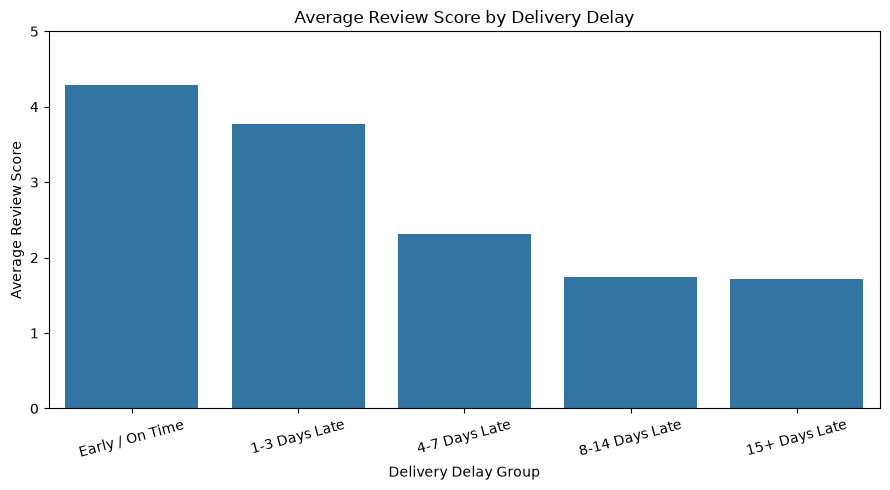

In [18]:
# Visualize the average review score by delivery delay using a bar plot
plt.figure(figsize=(9, 5))

sns.barplot(
    data=delay_review_summary,
    x="delay_group",
    y="average_review_score"
)

plt.title("Average Review Score by Delivery Delay")
plt.xlabel("Delivery Delay Group")
plt.ylabel("Average Review Score")
plt.ylim(0, 5)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [19]:
# Categorize orders as late or on-time
orders_clean["is_late"] = (
    orders_clean["delivery_delay_days"]
    .gt(0)
    .where(orders_clean["delivery_delay_days"].notna())
)

print("Late delivery counts:")
print(orders_clean["is_late"].value_counts(dropna=False))

Late delivery counts:
is_late
False    88649
True      7827
NaN       2965
Name: count, dtype: int64


In [20]:
# Analyze the relationship between delivery performance and customer reviews
delivery_review_summary = (
    orders_clean[
        orders_clean["average_review_score"].notna() &
        orders_clean["is_late"].notna()
    ]
    .groupby("is_late")
    .agg(
        order_count=("order_id", "nunique"),
        average_review_score=("average_review_score", "mean"),
        median_review_score=("average_review_score", "median")
    )
    .reset_index()
)

display(delivery_review_summary)

,is_late,order_count,average_review_score,median_review_score
0,False,88168,4.294151,5.0
1,True,7662,2.566562,2.0


## 16. Order Value, Freight Cost, and Customer Satisfaction

Order characteristics may also be associated with customer satisfaction.

This section examines whether order value and freight cost differ across customer review scores. The analysis focuses on observed relationships rather than assuming that higher or lower spending directly causes changes in satisfaction.

In [21]:
# Visualize the average review score by delivery status using a bar plot
value_review_summary = (
    orders_clean[
        orders_clean["average_review_score"].notna()
    ]
    .groupby("average_review_score")
    .agg(
        order_count=("order_id", "nunique"),
        average_order_value=("total_order_value", "mean"),
        median_order_value=("total_order_value", "median"),
        average_freight_value=("total_freight_value", "mean")
    )
    .reset_index()
)

display(value_review_summary)

,average_review_score,order_count,average_order_value,median_order_value,average_freight_value
0,1.000000,11316,166.972587,99.000,27.749845
1,1.500000,8,166.135000,132.870,38.567500
2,2.000000,3125,145.613647,89.900,26.247231
3,2.500000,34,107.830303,74.400,25.397273
4,3.000000,8136,127.637940,82.990,23.564195
5,3.333333,1,26.000000,26.000,16.110000
6,3.500000,25,122.310400,99.900,21.335200
7,4.000000,19018,132.482081,84.000,22.374608
8,4.333333,1,34.990000,34.990,7.780000
9,4.500000,54,98.578704,61.485,23.311111


In [22]:
# Visualize the average order value by review score using a bar plot
orders_clean["review_score_group"] = (
    orders_clean["average_review_score"]
    .round()
)

score_value_summary = (
    orders_clean[
        orders_clean["review_score_group"].notna()
    ]
    .groupby("review_score_group")
    .agg(
        order_count=("order_id", "nunique"),
        average_order_value=("total_order_value", "mean"),
        median_order_value=("total_order_value", "median"),
        average_freight_value=("total_freight_value", "mean")
    )
    .reset_index()
)

display(score_value_summary)

,review_score_group,order_count,average_order_value,median_order_value,average_freight_value
0,1.0,11316,166.972587,99.00,27.749845
1,2.0,3167,145.264845,89.90,26.269948
2,3.0,8137,127.625367,82.97,23.563273
3,4.0,19098,132.367607,84.00,22.375132
4,5.0,56955,134.674662,84.99,21.713652


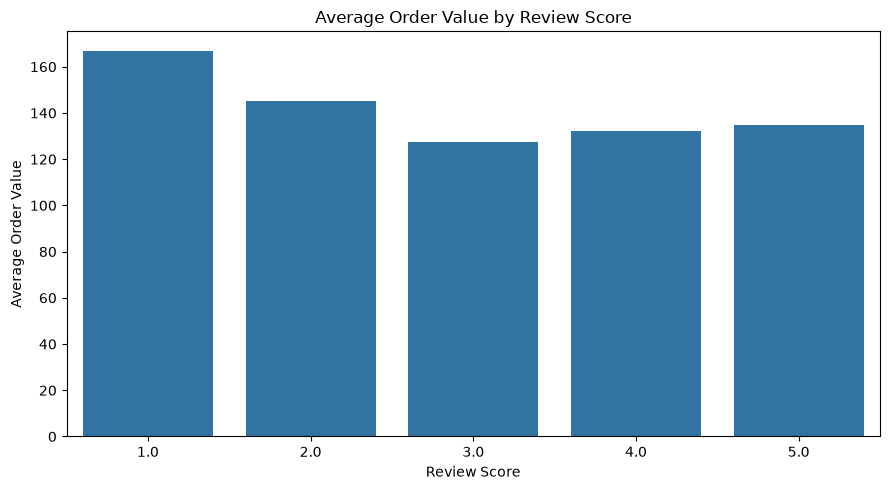

In [23]:
# Visualize the average order value by review score using a bar plot
plt.figure(figsize=(9, 5))

sns.barplot(
    data=score_value_summary,
    x="review_score_group",
    y="average_order_value"
)

plt.title("Average Order Value by Review Score")
plt.xlabel("Review Score")
plt.ylabel("Average Order Value")
plt.tight_layout()
plt.show()

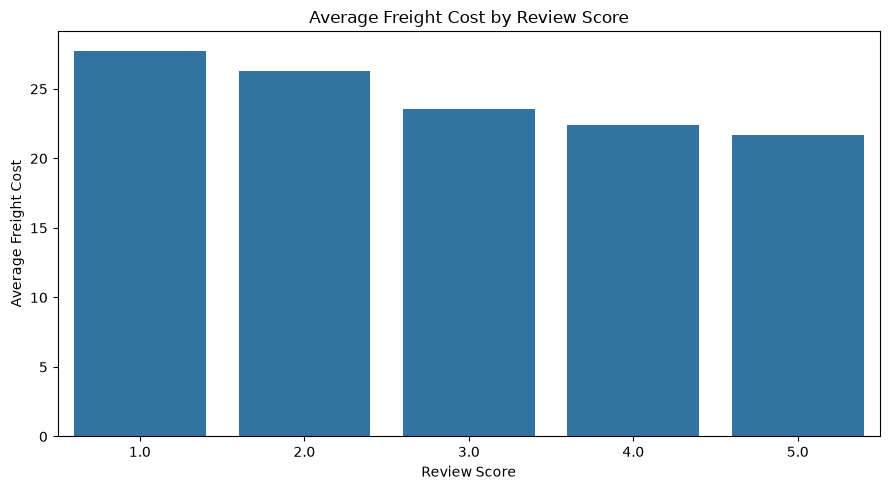

In [24]:
# Visualize the average freight value by review score using a bar plot
plt.figure(figsize=(9, 5))

sns.barplot(
    data=score_value_summary,
    x="review_score_group",
    y="average_freight_value"
)

plt.title("Average Freight Cost by Review Score")
plt.xlabel("Review Score")
plt.ylabel("Average Freight Cost")
plt.tight_layout()
plt.show()

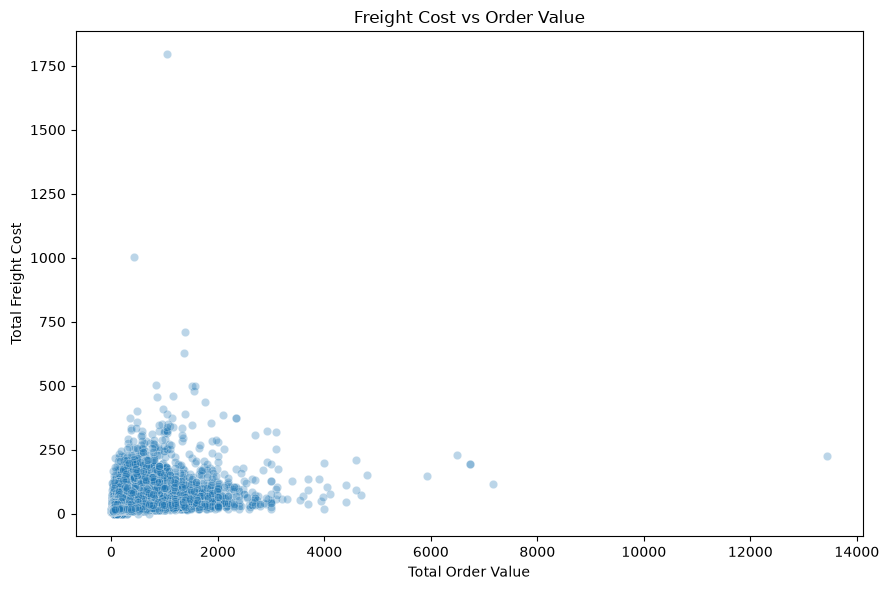

In [25]:
# Visualize the relationship between total order value and total freight value using a scatter plot
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=orders_clean[
        orders_clean["total_order_value"].notna() &
        orders_clean["total_freight_value"].notna()
    ],
    x="total_order_value",
    y="total_freight_value",
    alpha=0.3
)

plt.title("Freight Cost vs Order Value")
plt.xlabel("Total Order Value")
plt.ylabel("Total Freight Cost")
plt.tight_layout()
plt.show()

In [28]:
# Calculate the correlation between total order value and total freight value
freight_order_data = orders_clean[
    orders_clean["total_order_value"].notna() &
    orders_clean["total_freight_value"].notna()
][
    ["total_order_value", "total_freight_value"]
]

pearson_corr = freight_order_data["total_order_value"].corr(
    freight_order_data["total_freight_value"],
    method="pearson"
)

spearman_corr = freight_order_data["total_order_value"].corr(
    freight_order_data["total_freight_value"],
    method="spearman"
)

print("Pearson correlation:", round(pearson_corr, 4))
print("Spearman correlation:", round(spearman_corr, 4))

Pearson correlation: 0.4128
Spearman correlation: 0.469


## 17. Product Category and Delivery Performance

Product characteristics may influence both delivery performance and customer experience.

This section examines delivery time, late-delivery rates, and review scores across product categories. Since individual orders can contain multiple products, category-level analysis is performed using the order-item dataset rather than assigning a single category to each order.

In [29]:
# Analyze the delivery performance of each product category
category_delivery = (
    order_item_analysis[
        order_item_analysis["delivery_time_days"].notna()
    ]
    .groupby("product_category_name_english")
    .agg(
        order_item_count=("order_id", "count"),
        unique_order_count=("order_id", "nunique"),
        average_delivery_time=("delivery_time_days", "mean"),
        median_delivery_time=("delivery_time_days", "median"),
        late_delivery_rate=("is_late", "mean"),
        average_review_score=("average_review_score", "mean")
    )
    .reset_index()
)

category_delivery["late_delivery_rate"] = (
    category_delivery["late_delivery_rate"] * 100
)

display(category_delivery.head(10))

,product_category_name_english,order_item_count,unique_order_count,average_delivery_time,median_delivery_time,late_delivery_rate,average_review_score
0,agro_industry_and_commerce,206,177,11.641859,9.537089,4.368932,4.087379
1,air_conditioning,289,246,12.256658,9.384259,3.806228,4.052817
2,art,197,195,11.356613,9.596019,7.614213,4.082051
3,arts_and_craftmanship,24,23,5.719785,5.110741,8.333333,4.125000
4,audio,362,348,13.320865,10.660914,12.707182,3.836592
5,auto,4139,3809,12.226115,9.779965,8.287026,4.115788
6,baby,2982,2809,12.516417,10.016597,8.786050,4.078236
7,bed_bath_table,10953,9272,12.806463,10.391516,8.399525,3.923968
8,books_general_interest,536,495,11.613084,9.651991,6.529851,4.511278
9,books_imported,57,50,8.126521,6.368021,3.508772,4.508772


In [31]:
# Filter product categories with at least 500 order items and sort by late delivery rate
category_delivery_filtered = (
    category_delivery[
        category_delivery["order_item_count"] >= 500
    ]
    .sort_values(
        "late_delivery_rate",
        ascending=False
    )
)

print(
    "Categories with at least 500 order items:",
    len(category_delivery_filtered)
)

display(
    category_delivery_filtered[
        [
            "product_category_name_english",
            "order_item_count",
            "unique_order_count",
            "average_delivery_time",
            "median_delivery_time",
            "late_delivery_rate",
            "average_review_score"
        ]
    ]
)

Categories with at least 500 order items: 28


,product_category_name_english,order_item_count,unique_order_count,average_delivery_time,median_delivery_time,late_delivery_rate,average_review_score
26,electronics,2729,2517,12.885882,11.003056,9.747160,4.067159
72,unknown,1537,1392,12.792694,10.706505,9.368900,3.938689
43,health_beauty,9467,8649,11.980525,9.499387,9.063061,4.189689
57,office_furniture,1668,1254,20.841449,19.023652,8.932854,3.513301
6,baby,2982,2809,12.516417,10.016597,8.786050,4.078236
56,musical_instruments,651,611,12.980613,10.381632,8.602151,4.221705
39,furniture_decor,8160,6307,12.880255,10.756962,8.431373,3.953775
7,bed_bath_table,10953,9272,12.806463,10.391516,8.399525,3.923968
70,telephony,4430,4093,12.861938,10.799115,8.329571,3.994323
5,auto,4139,3809,12.226115,9.779965,8.287026,4.115788


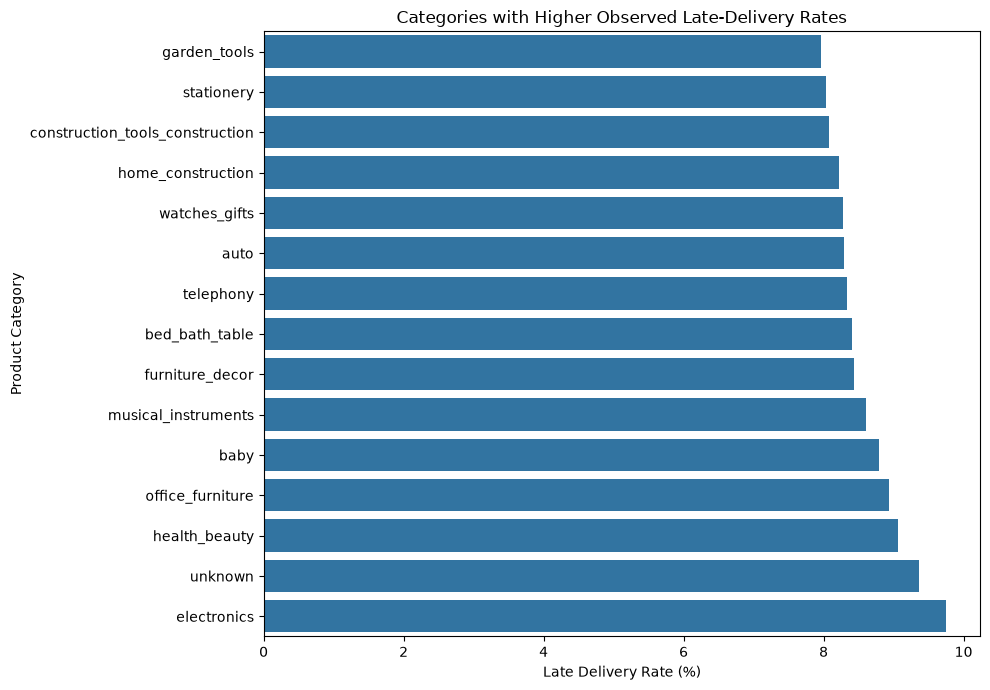

In [32]:
# Visualize the top 15 categories with higher observed late-delivery rates using a bar plot
top_late_categories = (
    category_delivery_filtered
    .sort_values("late_delivery_rate", ascending=False)
    .head(15)
    .sort_values("late_delivery_rate")
)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_late_categories,
    x="late_delivery_rate",
    y="product_category_name_english"
)

plt.title("Categories with Higher Observed Late-Delivery Rates")
plt.xlabel("Late Delivery Rate (%)")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()

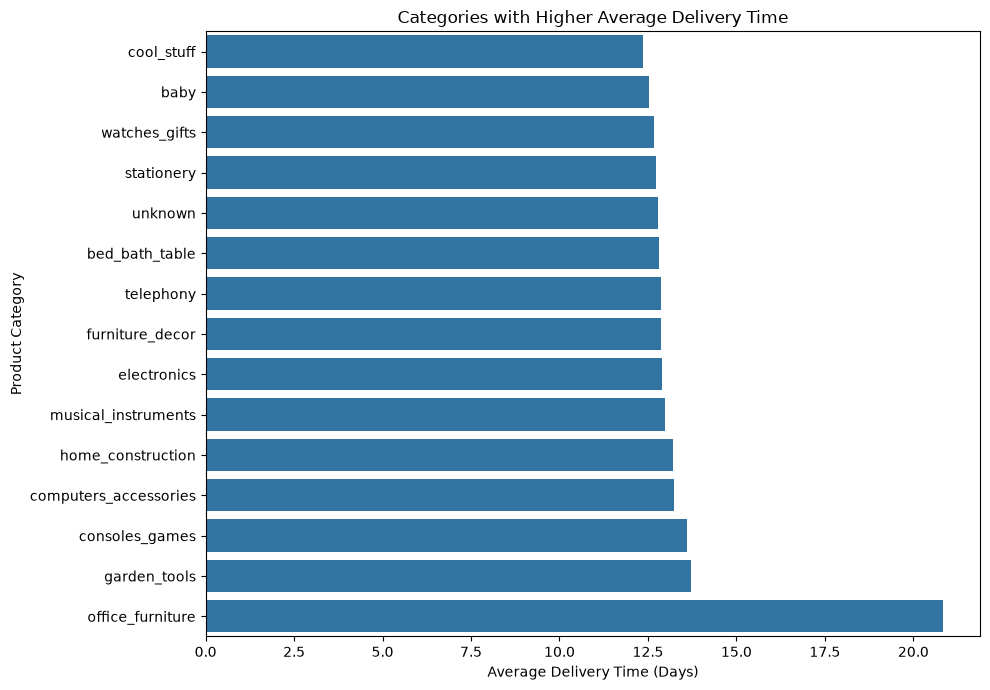

In [33]:
# Visualize the top 15 categories with higher average delivery time using a bar plot
top_delivery_time_categories = (
    category_delivery_filtered
    .sort_values("average_delivery_time", ascending=False)
    .head(15)
    .sort_values("average_delivery_time")
)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_delivery_time_categories,
    x="average_delivery_time",
    y="product_category_name_english"
)

plt.title("Categories with Higher Average Delivery Time")
plt.xlabel("Average Delivery Time (Days)")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()

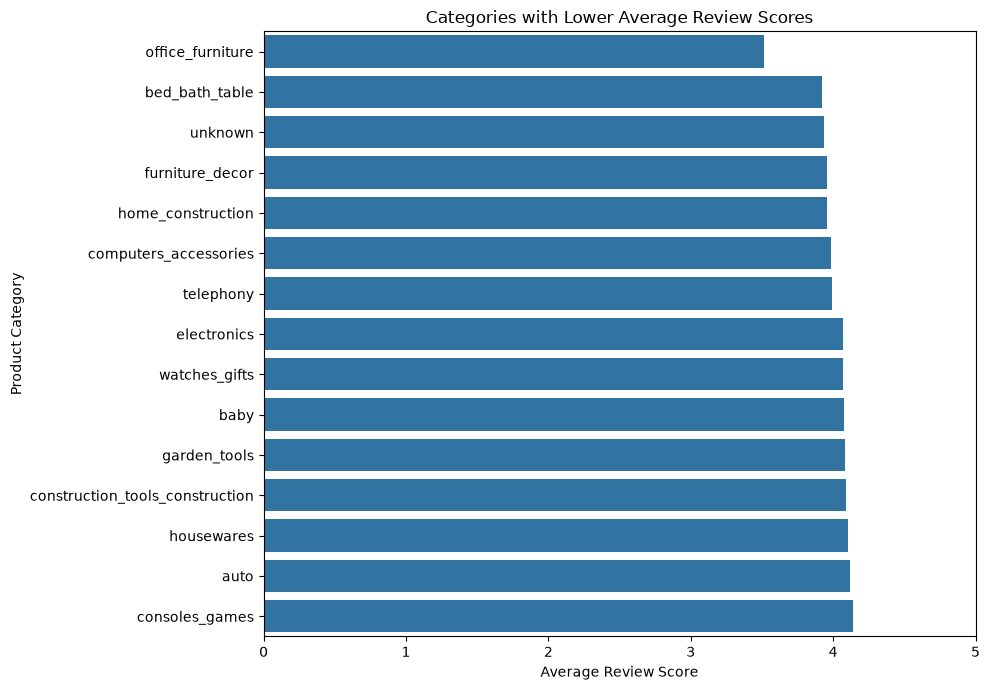

In [35]:
# Visualize the top 15 categories with lower average review scores using a bar plot
top_review_categories = (
    category_delivery_filtered
    .sort_values("average_review_score")
    .head(15)
)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_review_categories,
    x="average_review_score",
    y="product_category_name_english"
)

plt.title("Categories with Lower Average Review Scores")
plt.xlabel("Average Review Score")
plt.ylabel("Product Category")
plt.xlim(0, 5)

plt.tight_layout()
plt.show()

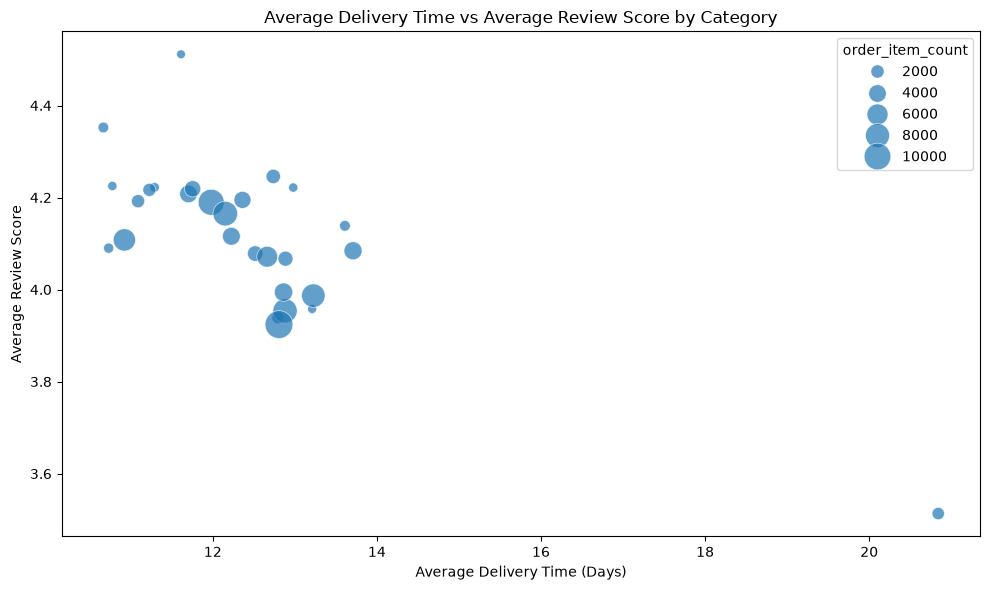

In [36]:
# Visualize the relationship between average delivery time and average review score by category using a scatter plot
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=category_delivery_filtered,
    x="average_delivery_time",
    y="average_review_score",
    size="order_item_count",
    sizes=(40, 400),
    alpha=0.7
)

plt.title("Average Delivery Time vs Average Review Score by Category")
plt.xlabel("Average Delivery Time (Days)")
plt.ylabel("Average Review Score")

plt.tight_layout()
plt.show()

In [38]:
# Calculate the correlation between average delivery time and average review score by category
category_relationship = category_delivery_filtered[
    [
        "average_delivery_time",
        "average_review_score"
    ]
].dropna()

category_pearson = category_relationship[
    "average_delivery_time"
].corr(
    category_relationship["average_review_score"],
    method="pearson"
)

category_spearman = category_relationship[
    "average_delivery_time"
].corr(
    category_relationship["average_review_score"],
    method="spearman"
)

print(
    "Category-level Pearson correlation:",
    round(category_pearson, 4)
)

print(
    "Category-level Spearman correlation:",
    round(category_spearman, 4)
)

Category-level Pearson correlation: -0.7804
Category-level Spearman correlation: -0.6196


In [39]:
# Calculate the correlation between average delivery time and average review score by category, excluding "office_furniture"
category_without_office = category_delivery_filtered[
    category_delivery_filtered["product_category_name_english"]
    != "office_furniture"
][
    [
        "average_delivery_time",
        "average_review_score"
    ]
].dropna()

pearson_without_office = (
    category_without_office["average_delivery_time"]
    .corr(
        category_without_office["average_review_score"],
        method="pearson"
    )
)

spearman_without_office = (
    category_without_office["average_delivery_time"]
    .corr(
        category_without_office["average_review_score"],
        method="spearman"
    )
)

print(
    "Pearson without office furniture:",
    round(pearson_without_office, 4)
)

print(
    "Spearman without office furniture:",
    round(spearman_without_office, 4)
)

Pearson without office furniture: -0.5415
Spearman without office furniture: -0.5757
